In [26]:
!pip install torch torchvision torchaudio torch-geometric scikit-learn matplotlib -q

In [27]:
# =============================================================
# SCM-GNN PIPELINE
# Accepts DAT file -> Windows -> Covariance -> Graphs -> SCM-GNN
# =============================================================


#!pip install -q pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv torch_geometric -f https://data.pyg.org/whl/torch-2.1.0+cu121.html

import numpy as np, math, time
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import ChebConv, SAGPooling, global_mean_pool, global_max_pool

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


Using: cpu


In [28]:

# =============================================================
# 1. PARAMETERS
# =============================================================
dat_path = "/content/ReadyMade_Dataset(FM).dat"   # <<=== YOUR DAT FILE
dtype = np.float32

sample_size = 100       # window length
num_signal_windows = 800
num_noise_windows  = 800

snr_db = -5           # AWGN for signal windows
zeta = 8                # time-delay size => covariance is (zeta x zeta)
top_k = 8               # edges per node
use_imag = True

batch_size = 200
epochs = 50

# =============================================================
# 2. LOAD .DAT FILE
# =============================================================
raw = np.fromfile(dat_path, dtype=dtype)
print("Loaded raw samples:", raw.shape)

# 1D real signal (ANN code used real FM signal)
raw = raw.reshape(-1)

# Optional filtering from ANN code:
raw = raw[np.logical_and(raw > 1e-7, raw < 1)]
print("Filtered samples:", raw.shape)

# =============================================================
# 3. AWGN
# =============================================================
def bandpower(x):
    return np.mean(x**2)

def awgn(x, snr_db):
    noise = np.random.randn(*x.shape)
    snr_lin = 10**(snr_db/10)
    var_signal = snr_lin * bandpower(noise)
    x_norm = math.sqrt(var_signal) * (x / math.sqrt(bandpower(x)))
    return x_norm + noise










Loaded raw samples: (3204096,)
Filtered samples: (1598392,)


In [29]:
# =============================================================
# 4. Create signal & noise windows
# =============================================================
def create_windows(signal, num_windows, sample_size, snr_db=None):
    """If snr_db is None -> noise windows. Else -> AWGN applied."""
    X = []

    if snr_db is not None:
        sig = signal[:num_windows*sample_size]
        sig = sig.reshape(-1)
        sig = awgn(sig, snr_db)
    else:
        sig = np.random.randn(num_windows*sample_size)

    for i in range(num_windows):
        win = sig[i*sample_size:(i+1)*sample_size]
        X.append(win.copy())

    return np.array(X)

signal_windows = create_windows(raw, num_signal_windows, sample_size, snr_db)
noise_windows  = create_windows(raw, num_noise_windows,  sample_size, snr_db=None)

print("Signal windows:", signal_windows.shape)
print("Noise windows:", noise_windows.shape)

Signal windows: (800, 100)
Noise windows: (800, 100)


In [30]:

# =============================================================
# 5. Compute time-delay covariance Ry (zeta x zeta)
# =============================================================
def compute_cov(window, zeta):
    """
    window: 1D real window
    Returns: (zeta x zeta) complex covariance matrix
    """
    N = len(window)
    denom = N - (zeta - 1)
    R = np.zeros((zeta, zeta), dtype=complex)

    for tau1 in range(zeta):
        for tau2 in range(zeta):
            s = 0
            for t in range(zeta-1, N):
                v1 = window[t-tau1]
                v2 = window[t-tau2]
                s += v1 * np.conjugate(v2)
            R[tau1, tau2] = s / denom

    return R

# =============================================================
# 6. Convert covariance matrix to graph
# =============================================================
def covariance_to_graph(R, top_k=2, use_imag=True):
    """
    R: (zeta x zeta) complex matrix
    nodes = zeta*zeta
    features = real+imag of each block element
    edges = cosine similarity neighbors
    """
    zeta = R.shape[0]
    Q = zeta*zeta

    feats = []  # node features
    for r in range(zeta):
        for c in range(zeta):
            val = R[r,c]
            if use_imag:
                feats.append([np.real(val), np.imag(val)])
            else:
                feats.append([np.real(val)])

    X = np.array(feats, dtype=np.float32)

    # Cosine similarity
    norms = np.linalg.norm(X, axis=1, keepdims=True) + 1e-12
    Xn = X / norms
    S = Xn @ Xn.T
    np.fill_diagonal(S, 0)

    # Build edges
    edge_src, edge_dst = [], []
    for i in range(Q):
        k = min(top_k, Q-1)
        neigh_idx = np.argsort(-S[i])[:k]
        for j in neigh_idx:
            edge_src.append(i); edge_dst.append(int(j))
            edge_src.append(int(j)); edge_dst.append(i)

    edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)
    x = torch.tensor(X, dtype=torch.float)

    return Data(x=x, edge_index=edge_index)

In [31]:
# =============================================================
# 7. Build graphs + labels
# =============================================================
graphs = []
labels = []

for w in signal_windows:
    R = compute_cov(w, zeta)
    g = covariance_to_graph(R, top_k, use_imag)
    g.y = torch.tensor([1], dtype=torch.long)
    graphs.append(g)

for w in noise_windows:
    R = compute_cov(w, zeta)
    g = covariance_to_graph(R, top_k, use_imag)
    g.y = torch.tensor([0], dtype=torch.long)
    graphs.append(g)

print("Total graphs:", len(graphs))

# =============================================================
# 8. Train/test split
# =============================================================
perm = np.random.permutation(len(graphs))
split = int(0.8*len(graphs))
train_idx = perm[:split]
test_idx  = perm[split:]

train_graphs = [graphs[i] for i in train_idx]
test_graphs  = [graphs[i] for i in test_idx]

train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_graphs,  batch_size=batch_size)


Total graphs: 1600


/tmp/ipython-input-842806709.py:32: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
/tmp/ipython-input-842806709.py:33: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader  = DataLoader(test_graphs,  batch_size=batch_size)


In [32]:
# =============================================================
# 9. Define SCM-GNN
# =============================================================
class SCMGNN(nn.Module):
    def __init__(self, in_features, hidden=32, K=3):
        super().__init__()
        self.lin = nn.Linear(in_features, hidden)
        self.bn0 = nn.BatchNorm1d(hidden)

        self.conv = ChebConv(hidden, hidden, K)
        self.bn1 = nn.BatchNorm1d(hidden)

        self.pool = SAGPooling(hidden, ratio=0.5)

        self.fc1 = nn.Linear(hidden*2, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.bn0(self.lin(x)))
        x = F.relu(self.bn1(self.conv(x, edge_index)))
        x, edge_index, _, batch, _, _ = self.pool(x, edge_index, None, batch)
        xm = global_mean_pool(x, batch)
        xM = global_max_pool(x, batch)
        h = torch.cat([xm, xM], dim=1)
        h = F.relu(self.fc1(h))
        return self.fc2(h)

in_feats = train_graphs[0].x.shape[1]
model = SCMGNN(in_feats).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)


# =============================================================
# 10. Training
# =============================================================
def train_epoch(model, loader):
    model.train()
    total = 0
    for batch in loader:
        batch = batch.to(device)
        opt.zero_grad()
        out = model(batch)
        loss = F.cross_entropy(out, batch.y)
        loss.backward()
        opt.step()
        total += loss.item() * batch.num_graphs
    return total / len(loader.dataset)

def evaluate(model, loader):
    model.eval()
    ys=[]; probs=[]
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            p = F.softmax(out, dim=1)[:,1].cpu().numpy()
            ys.extend(batch.y.cpu().numpy().tolist())
            probs.extend(p.tolist())
    return np.array(ys), np.array(probs)

for ep in range(epochs):
    loss = train_epoch(model, train_loader)
    y_true, y_prob = evaluate(model, test_loader)
    auc = roc_auc_score(y_true, y_prob)
    print(f"Epoch {ep+1}/{epochs} | Loss={loss:.4f} | AUC={auc:.4f}")

Epoch 1/50 | Loss=0.6177 | AUC=0.9153
Epoch 2/50 | Loss=0.5165 | AUC=0.8166
Epoch 3/50 | Loss=0.4679 | AUC=0.9694
Epoch 4/50 | Loss=0.3931 | AUC=0.9670
Epoch 5/50 | Loss=0.3553 | AUC=0.9700
Epoch 6/50 | Loss=0.2956 | AUC=0.9748
Epoch 7/50 | Loss=0.2665 | AUC=0.9705
Epoch 8/50 | Loss=0.2462 | AUC=0.9688
Epoch 9/50 | Loss=0.2472 | AUC=0.9708
Epoch 10/50 | Loss=0.2248 | AUC=0.9722
Epoch 11/50 | Loss=0.2157 | AUC=0.9719
Epoch 12/50 | Loss=0.2053 | AUC=0.9703
Epoch 13/50 | Loss=0.1952 | AUC=0.9690
Epoch 14/50 | Loss=0.2019 | AUC=0.9704
Epoch 15/50 | Loss=0.1998 | AUC=0.9712
Epoch 16/50 | Loss=0.2084 | AUC=0.9713
Epoch 17/50 | Loss=0.1967 | AUC=0.9711
Epoch 18/50 | Loss=0.1941 | AUC=0.9727
Epoch 19/50 | Loss=0.1773 | AUC=0.9739
Epoch 20/50 | Loss=0.1752 | AUC=0.9733
Epoch 21/50 | Loss=0.1773 | AUC=0.9740
Epoch 22/50 | Loss=0.1797 | AUC=0.9754
Epoch 23/50 | Loss=0.1856 | AUC=0.9689
Epoch 24/50 | Loss=0.2167 | AUC=0.9756
Epoch 25/50 | Loss=0.1810 | AUC=0.9678
Epoch 26/50 | Loss=0.1826 | AUC=0.


Final Accuracy: 0.809375
Final AUC: 0.969159719776134


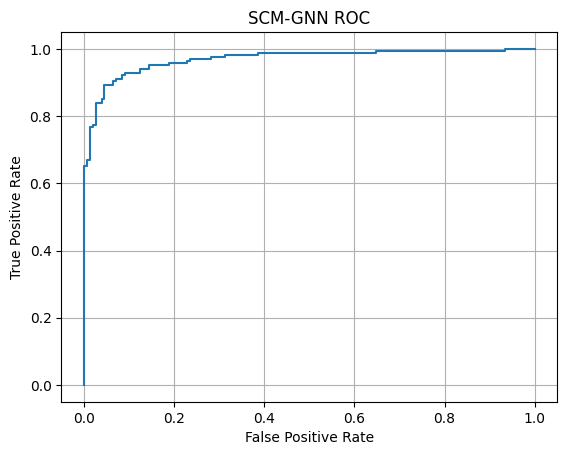

In [33]:
# =============================================================
# 11. Plot ROC + final metrics
# =============================================================
y_true, y_prob = evaluate(model, test_loader)
y_pred = (y_prob>=0.5).astype(int)

acc = accuracy_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)
print("\nFinal Accuracy:", acc)
print("Final AUC:", auc)

fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.plot(fpr, tpr, label=f'SCM-GNN AUC= {auc}')
plt.title("SCM-GNN ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()
plt.show()


In [34]:
# =============================================================
# 12. Nose Windows
# =============================================================

def create_noise_windows(num_windows, sample_size):

   # Produces pure noise windows (H0 hypothesis).
    noise = np.random.randn(num_windows * sample_size, 1)
    windows = np.split(noise, num_windows)
    return windows
def get_scores(model, windows, zeta, top_k, use_imag):

    #Returns model probability scores for class H1 (signal-present).

    scores = []

    for w in windows:
        R = compute_cov(w, zeta)
        g = covariance_to_graph(R, top_k, use_imag)
        g.batch = torch.zeros(g.x.size(0), dtype=torch.long)

        g = g.to(device)
        with torch.no_grad():
            out = model(g)
            prob = F.softmax(out, dim=1)[0, 1].item()
        scores.append(prob)

    return np.array(scores)
def get_scores(model, windows, zeta, top_k, use_imag):

   # Returns model probability scores for class H1 (signal-present).

    scores = []

    for w in windows:
        R = compute_cov(w, zeta)
        g = covariance_to_graph(R, top_k, use_imag)
        g.batch = torch.zeros(g.x.size(0), dtype=torch.long)

        g = g.to(device)
        with torch.no_grad():
            out = model(g)
            prob = F.softmax(out, dim=1)[0, 1].item()
        scores.append(prob)

    return np.array(scores)


Computing Pd(SNR) at Pf = 0.1 ...


/tmp/ipython-input-2593986136.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  R[tau1, tau2] = s / denom


SNR=-20 dB | τ=0.8938 | Pd=0.0900
SNR=-18 dB | τ=0.9058 | Pd=0.1175
SNR=-16 dB | τ=0.8557 | Pd=0.1925
SNR=-14 dB | τ=0.8457 | Pd=0.3050
SNR=-12 dB | τ=0.8557 | Pd=0.3800
SNR=-10 dB | τ=0.8196 | Pd=0.6325
SNR= -8 dB | τ=0.8878 | Pd=0.7050
SNR= -6 dB | τ=0.8717 | Pd=0.8850
SNR= -4 dB | τ=0.8717 | Pd=0.9375
SNR= -2 dB | τ=0.8537 | Pd=0.9825
SNR=  0 dB | τ=0.8938 | Pd=1.0000
SNR=  2 dB | τ=0.8858 | Pd=1.0000
SNR=  4 dB | τ=0.8377 | Pd=1.0000
SNR=  6 dB | τ=0.8517 | Pd=1.0000


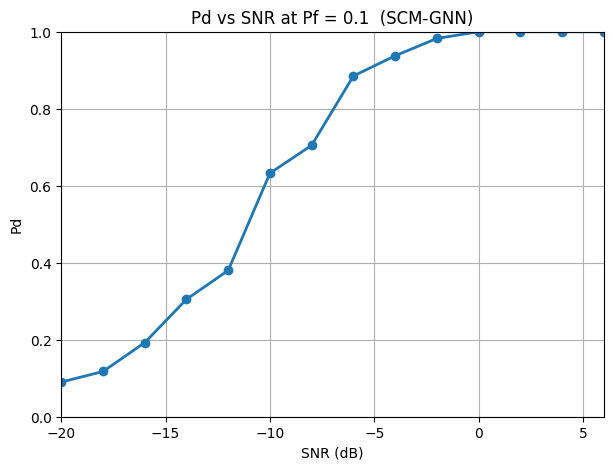

In [35]:
# =============================================================
# 13.Pd vs SNR curve at fixed PFA = 0.1
# =============================================================

target_pf = 0.1
snr_range = list(range(-20, 8, 2))
num_windows = 400      # number of windows for H0 and H1 per SNR
thresholds = np.linspace(0, 1, 500)

Pd_at_fixed_pf = {}

print("\nComputing Pd(SNR) at Pf = 0.1 ...")

for snr in snr_range:

    # ----------------- 1. Generate H1 (signal present) -----------------
    H1_windows = create_windows(raw, num_windows, sample_size, snr)
    H1_scores = get_scores(model, H1_windows, zeta, top_k, use_imag)

    # ----------------- 2. Generate H0 (noise only) ---------------------
    H0_windows = create_noise_windows(num_windows, sample_size)
    H0_scores = get_scores(model, H0_windows, zeta, top_k, use_imag)

    # ----------------- 3. Determine threshold τ for Pf=0.1 --------------
    Pf_list = []
    for τ in thresholds:
        Pf = np.mean(H0_scores >= τ)
        Pf_list.append(Pf)

    Pf_list = np.array(Pf_list)

    # Find τ where Pf is closest to 0.1
    idx = np.argmin(np.abs(Pf_list - target_pf))
    τ_pfa = thresholds[idx]

    # ----------------- 4. Compute Pd at this τ --------------------------
    Pd = np.mean(H1_scores >= τ_pfa)
    Pd_at_fixed_pf[snr] = Pd

    print(f"SNR={snr:>3d} dB | τ={τ_pfa:.4f} | Pd={Pd:.4f}")

plt.figure(figsize=(7,5))
plt.plot(snr_range, [Pd_at_fixed_pf[s] for s in snr_range], marker='o', linewidth=2)
plt.title("Pd vs SNR at Pf = 0.1  (SCM-GNN)")
plt.xlabel("SNR (dB)")
plt.ylabel("Pd")
plt.grid(True)
plt.ylim([0, 1])
plt.xlim([snr_range[0], snr_range[-1]])
plt.show()



Computing ROC curves (Pd vs Pf) for each SNR...



/tmp/ipython-input-2593986136.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  R[tau1, tau2] = s / denom


SNR=-20 dB: Completed ROC Generation
SNR=-18 dB: Completed ROC Generation
SNR=-16 dB: Completed ROC Generation
SNR=-14 dB: Completed ROC Generation
SNR=-12 dB: Completed ROC Generation
SNR=-10 dB: Completed ROC Generation
SNR=-8 dB: Completed ROC Generation
SNR=-6 dB: Completed ROC Generation
SNR=-4 dB: Completed ROC Generation
SNR=-2 dB: Completed ROC Generation
SNR=0 dB: Completed ROC Generation
SNR=2 dB: Completed ROC Generation
SNR=4 dB: Completed ROC Generation
SNR=6 dB: Completed ROC Generation


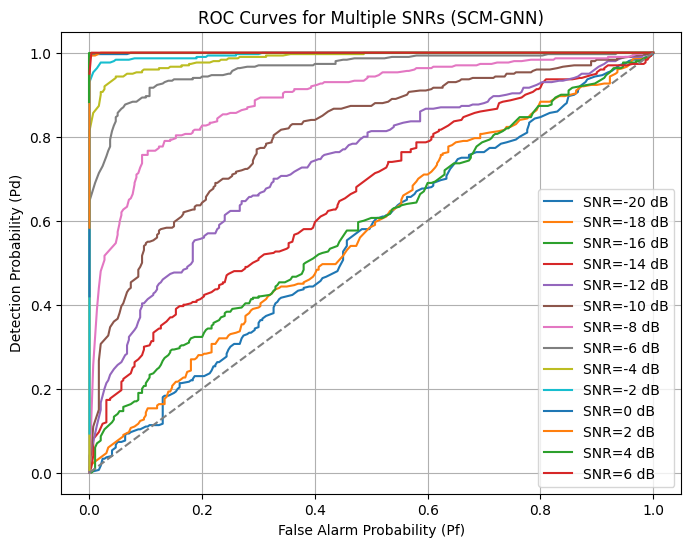

In [36]:
# =============================================================
# 14.All SNR curves in one graph
# =============================================================



snr_range = list(range(-20, 8, 2))
num_windows = 300
thresholds = np.linspace(0, 1, 200)

ROC_results = {}        # stores FPR/TPR for each SNR
PdPf_results = {}       # Pd(Pf) curve for each SNR


print("\nComputing ROC curves (Pd vs Pf) for each SNR...\n")

for snr in snr_range:

    # ---------- 1. Create H1 (signal-present) windows ----------
    H1_windows = create_windows(raw, num_windows, sample_size, snr)
    H1_scores = get_scores(model, H1_windows, zeta, top_k, use_imag)

    # ---------- 2. Create H0 (noise-only) windows ----------
    H0_windows = create_noise_windows(num_windows, sample_size)
    H0_scores = get_scores(model, H0_windows, zeta, top_k, use_imag)

    Pd_list = []
    Pf_list = []

    # ---------- 3. Sweep thresholds ----------
    for τ in thresholds:
        Pd = np.mean(H1_scores >= τ)
        Pf = np.mean(H0_scores >= τ)

        Pd_list.append(Pd)
        Pf_list.append(Pf)

    # ---------- Save ----------
    ROC_results[snr]  = (Pf_list, Pd_list)
    PdPf_results[snr] = (Pf_list, Pd_list)

    print(f"SNR={snr} dB: Completed ROC Generation")

plt.figure(figsize=(8,6))

for snr in snr_range:
    Pf, Pd = ROC_results[snr]
    plt.plot(Pf, Pd, label=f"SNR={snr} dB")

plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Alarm Probability (Pf)")
plt.ylabel("Detection Probability (Pd)")
plt.title("ROC Curves for Multiple SNRs (SCM-GNN)")
plt.grid(True)
plt.legend()
plt.show()
